# Spiking spike-initiation benchmark analysis — losses × (gradient descent vs. Nelder-Mead)

With adaptation off (`a=b=0`) and only the spike-initiation params
(`v_T, delta_T, v_reset`) free, this notebook asks two questions:

1. **Per loss:** how low can each optimizer drive that loss, and does gradient
   descent (`grad`) match or beat Nelder-Mead (`nm`)? Paired across
   `scenario_idx` (both optimizers fit the same ground truth from the same fixed
   init).
2. **Across losses:** which differentiable loss recovers the parameters best?
   Raw loss values are **not** comparable across losses (each has its own scale),
   so the cross-loss comparison is done on the **loss-agnostic** evaluation
   metrics from the clean non-surrogate re-sim — coincidence factor Γ, accuracy
   success, parameter-recovery error, first-spike/rate error.

The set of losses is discovered from `results_spiking.csv` (currently
`ttfs_rate`, `van_rossum`, `guarino`). Every per-loss figure is produced for each
loss in a loop; a final section ranks the losses and names the best for the
`grad` optimizer.

**Caveat on the iteration axis:** one grad "iter" is a forward+backward pass (one
Adam step), one NM "iter" is a single forward loss evaluation. They are roughly
comparable as loss-evaluations but grad's is more expensive per step, so
`elapsed_s` is the fair cost metric.

Reads `results_spiking.csv` + `results_spiking_curves.csv`. Figures are plotted
inline **and** saved to `figures/`, namespaced per loss
(`spiking_<loss>_loss_curves.pdf`, `_convergence.pdf`, `_fit_quality.pdf`,
`_example_trajectories.pdf`, `_example_fits.pdf`) plus the cross-loss
`spiking_loss_comparison.pdf`.

In [1]:
import csv
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import binomtest, wilcoxon

# Resolve the 5_code dir whether the notebook runs from 5_code/ or 5_code/notebooks/.
ROOT = Path.cwd()
if not (ROOT / "results_spiking.csv").exists():
    ROOT = ROOT.parent
FIGS = ROOT / "figures"
FIGS.mkdir(exist_ok=True)

METHOD = "grad"          # method under test
BASELINE = "nm"
PARAMS = ["v_T", "delta_T", "v_reset"]
# LOSSES is discovered from the CSV in the next cell.

# Plot loss curves as best-so-far (running minimum) rather than raw per-epoch
# loss. This is the like-for-like convergence metric: Adam's raw curve is
# non-monotone by design (its step is ~lr regardless of the small gradient, so
# on this staircase loss it finds the basin then overshoots back out), whereas
# Nelder-Mead's contracting simplex rarely worsens its best. Best-so-far compares
# "lowest loss achieved by iteration k" for both. Set False to see raw overshoot.
BEST_SO_FAR = True


def curve_view(c):
    """Best-so-far (cumulative min) view of a loss curve, or raw if disabled."""
    c = np.asarray(c)
    return np.minimum.accumulate(c) if BEST_SO_FAR else c


# --- Plot style (matches the thesis figure defaults) ------------------------
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["DejaVu Serif", "Times New Roman", "Times"],
    "mathtext.fontset": "cm",
    "axes.labelsize": 10, "axes.titlesize": 10, "axes.titleweight": "regular",
    "axes.linewidth": 0.6, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.fontsize": 8.5, "legend.frameon": False,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.linewidth": 0.4, "grid.alpha": 0.35,
    "pdf.fonttype": 42, "ps.fonttype": 42, "savefig.dpi": 300,
    "savefig.bbox": "tight", "savefig.pad_inches": 0.02,
})
COLORS = {"grad": "#0072B2", "nm": "#E69F00"}          # per-optimizer
LABELS = {"grad": r"$\nabla$ (Adam)", "nm": "Nelder-Mead"}
MARKERS = {"grad": "o", "nm": "^"}
LOSS_COLORS = {"ttfs_rate": "#009E73", "van_rossum": "#CC79A7",  # per-loss
               "guarino": "#56B4E9", "soft_dtw": "#D55E00"}


def loss_color(loss):
    return LOSS_COLORS.get(loss, "#777777")

In [2]:
def _f(v):
    try:
        return float(v)
    except (TypeError, ValueError):
        return float("nan")


ALL_ROWS = list(csv.DictReader(open(ROOT / "results_spiking.csv")))
ALL_CURVES = list(csv.DictReader(open(ROOT / "results_spiking_curves.csv")))

LOSSES = sorted({r["loss"] for r in ALL_ROWS})
BASES = sorted({r["base"] for r in ALL_ROWS})
DELTAS = sorted({_f(r["delta"]) for r in ALL_ROWS})


def _build_loss_data(loss):
    """Per-loss state: summary index + scenario ids + raw/aggregated curves."""
    rows = [r for r in ALL_ROWS if r["loss"] == loss]
    # index[(scenario_idx, optimizer)] -> summary row
    index = {(int(r["scenario_idx"]), r["optimizer"]): r for r in rows}
    sids = sorted({int(r["scenario_idx"]) for r in rows})

    crows = [r for r in ALL_CURVES if r["loss"] == loss]
    by_run: dict = {}  # (sid, base, opt) -> [(iter, loss_value), ...] (raw)
    for r in crows:
        key = (int(r["scenario_idx"]), r["base"], r["optimizer"])
        by_run.setdefault(key, []).append((int(r["iter"]), _f(r["loss_value"])))
    # curves[(base, opt)] -> [per-run curve, ...] in the configured view
    # (best-so-far by default, see curve_view / BEST_SO_FAR).
    curves: dict = {}
    for (sid, base, opt), pts in by_run.items():
        pts.sort()
        curves.setdefault((base, opt), []).append(
            curve_view([p[1] for p in pts]))
    return {"index": index, "sids": sids, "by_run": by_run, "curves": curves}


LOSS_DATA = {loss: _build_loss_data(loss) for loss in LOSSES}
print("losses:", LOSSES, " | curve view:",
      "best-so-far" if BEST_SO_FAR else "raw per-epoch")
print("bases :", BASES, " deltas:", DELTAS)
for loss in LOSSES:
    idx = LOSS_DATA[loss]["index"]
    n_err = sum(1 for r in idx.values() if _f(r["accuracy_success"]) < 0)
    print(f"  {loss:<12} runs={len(idx):4d}  errored={n_err}")


# --- Metric accessors (loss-agnostic; operate on a summary row) -------------

def _errored(row):
    return _f(row["accuracy_success"]) < 0  # -1 marks an errored run


def mean_param_err(row):
    return float(np.mean([_f(row[f"param_err_{p}"]) for p in PARAMS]))


def get_metric(row, metric):
    return mean_param_err(row) if metric == "param_err" else _f(row[metric])


# --- Paired (grad vs nm) helpers, parametrized by a loss's index/sids -------

def paired(index, sids, metric, base=None):
    """(grad, nm) arrays paired on scenario_idx. Drops missing/NaN/errored pairs."""
    a_vals, b_vals = [], []
    for sid in sids:
        ra, rb = index.get((sid, METHOD)), index.get((sid, BASELINE))
        if ra is None or rb is None:
            continue
        if base is not None and ra["base"] != base:
            continue
        if _errored(ra) or _errored(rb):
            continue
        va, vb = get_metric(ra, metric), get_metric(rb, metric)
        if not (np.isfinite(va) and np.isfinite(vb)):
            continue
        a_vals.append(va)
        b_vals.append(vb)
    return np.array(a_vals), np.array(b_vals)


def wilcoxon_report(a, b, higher_better=False):
    """Paired signed-rank. Default H1 = a < b (lower=better); flip if
    higher_better. Returns (p, a-win%, median(a-b))."""
    if len(a) < 6 or np.allclose(a, b):
        return float("nan"), float("nan"), float("nan")
    alt = "greater" if higher_better else "less"
    try:
        _, p = wilcoxon(a, b, alternative=alt)
    except ValueError:
        p = float("nan")
    cmp = (a > b) if higher_better else (a < b)
    win = float(np.mean(cmp) + 0.5 * np.mean(a == b))
    return p, win, float(np.median(a - b))


def mcnemar_success(index, sids, base=None):
    a, b = paired(index, sids, "accuracy_success", base)
    n10 = int(np.sum((a == 1) & (b == 0)))   # grad succeeds, nm doesn't
    n01 = int(np.sum((a == 0) & (b == 1)))   # nm succeeds, grad doesn't
    n = n10 + n01
    p = binomtest(min(n10, n01), n, 0.5).pvalue if n > 0 else float("nan")
    return n10, n01, p

losses: ['soft_dtw']  | curve view: best-so-far
bases : ['tonic']  deltas: [0.05, 0.1, 0.2]
  soft_dtw     runs= 120  errored=0


## Paired statistical tests (per loss)

For each loss, `grad` vs `nm`, paired on `scenario_idx`. The headline is the
achieved loss (lower = better); Γ is higher = better (direction flipped).
Wilcoxon signed-rank per metric, McNemar on the binary `accuracy_success`
outcome, plus LaTeX rows for the results table. This still compares the *two
optimizers within each loss* — the *across-loss* "which loss is best" comparison
is the final section.

In [3]:
METRICS = [("final_loss", "final loss", False),
           ("param_err", "mean |dparam|/range", False),
           ("first_spike_err_ms", "first-spike err (ms)", False),
           ("rate_rel_err", "rate rel err", False),
           ("gamma", "Gamma (higher better)", True),
           ("elapsed_s", "wall-clock s", False)]


def paired_tests(loss):
    LD = LOSS_DATA[loss]
    index, sids = LD["index"], LD["sids"]
    print("=" * 86)
    print(f"PAIRED TESTS [{loss}]: {METHOD} vs {BASELINE}  (lower=better unless noted)")
    print("=" * 86)
    groups = BASES + (["POOLED"] if len(BASES) > 1 else [])
    for base in groups:
        print(f"\n-- {base} --")
        print(f"{'metric':<24}{'n':>4}{'med d(grad-nm)':>16}{'grad win%':>11}{'p(Wilcox)':>11}")
        for metric, label, hb in METRICS:
            a, b = paired(index, sids, metric, None if base == "POOLED" else base)
            p, win, med = wilcoxon_report(a, b, higher_better=hb)
            print(f"{label:<24}{len(a):>4}{med:>16.4g}{100*win:>10.0f}%{p:>11.4f}")
        n10, n01, pmc = mcnemar_success(index, sids,
                                        None if base == "POOLED" else base)
        print(f"{'success (McNemar)':<24}{'':>4}grad/nm-only = {n10}/{n01}, p={pmc:.4f}")


for loss in LOSSES:
    paired_tests(loss)
    print()

print("=== LaTeX rows (grad vs nm, final loss, per loss × base) ===")
for loss in LOSSES:
    LD = LOSS_DATA[loss]
    for base in BASES:
        a, b = paired(LD["index"], LD["sids"], "final_loss", base)
        p, win, med = wilcoxon_report(a, b)
        sname = f"{loss} / {base}".replace("_", " ")
        print(rf"{sname} & ${med:+.4g}$ & ${100*win:.0f}\%$ & ${p:.3f}$ \\")

PAIRED TESTS [soft_dtw]: grad vs nm  (lower=better unless noted)

-- tonic --
metric                     n  med d(grad-nm)  grad win%  p(Wilcox)
final loss                60           4.312        28%     0.9991
mean |dparam|/range       60       0.0001586        47%     0.8017
first-spike err (ms)      60          0.5625        40%     0.9433
rate rel err              60               0        39%     0.8526
Gamma (higher better)     60        -0.05317        35%     0.9784
wall-clock s              60          0.4012         2%     1.0000
success (McNemar)           grad/nm-only = 8/22, p=0.0161

=== LaTeX rows (grad vs nm, final loss, per loss × base) ===
soft dtw / tonic & $+4.312$ & $28\%$ & $0.999$ \\


## Figure 1 — convergence: best-so-far loss vs iteration (median ± IQR), per loss

Per-run loss curves aggregated to the median trajectory with an inter-quartile
band, one figure per loss. Curves are **best-so-far** (running minimum, see
`BEST_SO_FAR`): the lowest loss achieved by iteration *k*. This is the fair
convergence comparison — Adam's raw per-epoch loss is non-monotone by design (it
finds the basin then overshoots on this staircase loss; cosine LR decay in the
benchmark now lets it settle), while Nelder-Mead's contracting simplex rarely
worsens its best. Each run is padded to the common length with its final value.

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


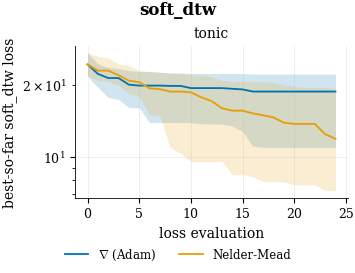

In [4]:
def median_iqr(curve_list):
    """Pad each curve to common length with its last value, then median + IQR."""
    if not curve_list:
        return None
    max_len = max(len(c) for c in curve_list)
    mat = np.array([np.concatenate([c, np.full(max_len - len(c), c[-1])])
                    for c in curve_list])
    return (np.median(mat, axis=0),
            np.percentile(mat, 25, axis=0), np.percentile(mat, 75, axis=0))


def _curve_ylabel(loss):
    return f"best-so-far {loss} loss" if BEST_SO_FAR else f"{loss} loss"


def fig_loss_curves(loss):
    curves = LOSS_DATA[loss]["curves"]  # already in best-so-far view
    fig, axes = plt.subplots(1, len(BASES), figsize=(2.3 * len(BASES) + 1.3, 2.8),
                             sharey=True, constrained_layout=True, squeeze=False)
    for ax, base in zip(axes[0], BASES):
        for m in ("grad", "nm"):
            res = median_iqr(curves.get((base, m), []))
            if res is None:
                continue
            med, lo, hi = res
            x = np.arange(len(med))
            ax.plot(x, med, color=COLORS[m], linewidth=1.3, label=LABELS[m])
            ax.fill_between(x, lo, hi, color=COLORS[m], alpha=0.18, linewidth=0)
        ax.set_yscale("log")
        ax.set_xlabel("loss evaluation")
        ax.set_title(base.replace("_", " "))
    axes[0][0].set_ylabel(_curve_ylabel(loss))
    fig.suptitle(loss, fontweight="bold")
    h, l = axes[0][0].get_legend_handles_labels()
    fig.legend(h, l, loc="outside lower center", ncol=2)
    fig.savefig(FIGS / f"spiking_{loss}_loss_curves.pdf")
    plt.show()


for loss in LOSSES:
    fig_loss_curves(loss)

## Figure 2 — perturbation scaling & cost, per loss

Median achieved loss and probability of an accuracy success (first-spike error
< 5 ms **and** rate error < 10 %) vs the perturbation scale δ, plus the
wall-clock cost per run. One figure per loss.

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


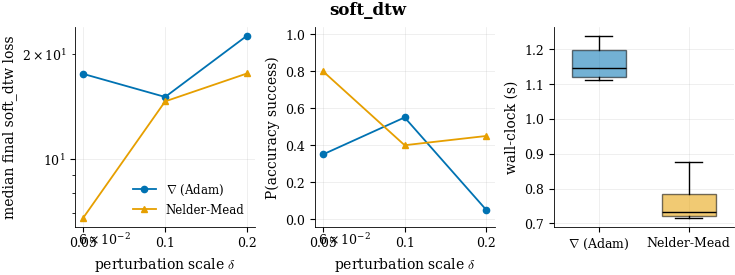

In [5]:
def fig_convergence(loss):
    index = LOSS_DATA[loss]["index"]
    fig, axes = plt.subplots(1, 3, figsize=(7.4, 2.8), constrained_layout=True)

    # (a) median final loss vs delta (per optimizer)
    ax = axes[0]
    for m in ("grad", "nm"):
        ys = []
        for d in DELTAS:
            vals = [_f(index[k]["final_loss"]) for k in index
                    if k[1] == m and _f(index[k]["delta"]) == d
                    and not _errored(index[k])]
            vals = [v for v in vals if np.isfinite(v)]
            ys.append(np.median(vals) if vals else float("nan"))
        ax.plot(DELTAS, ys, color=COLORS[m], marker=MARKERS[m], markersize=4.5,
                linewidth=1.3, label=LABELS[m])
    ax.set_yscale("log"); ax.set_xscale("log"); ax.set_xticks(DELTAS)
    ax.set_xticklabels([f"{d:g}" for d in DELTAS])
    ax.tick_params(axis="x", which="minor", length=0)
    ax.set_xlabel(r"perturbation scale $\delta$")
    ax.set_ylabel(f"median final {loss} loss"); ax.legend()

    # (b) P(accuracy success) vs delta
    ax = axes[1]
    for m in ("grad", "nm"):
        ys = []
        for d in DELTAS:
            vals = [int(_f(index[k]["accuracy_success"])) for k in index
                    if k[1] == m and _f(index[k]["delta"]) == d]
            vals = [v for v in vals if v in (0, 1)]
            ys.append(sum(vals) / len(vals) if vals else float("nan"))
        ax.plot(DELTAS, ys, color=COLORS[m], marker=MARKERS[m], markersize=4.5,
                linewidth=1.3, label=LABELS[m])
    ax.set_xscale("log"); ax.set_xticks(DELTAS)
    ax.set_xticklabels([f"{d:g}" for d in DELTAS])
    ax.tick_params(axis="x", which="minor", length=0)
    ax.set_xlabel(r"perturbation scale $\delta$")
    ax.set_ylabel("P(accuracy success)"); ax.set_ylim(-0.04, 1.04)

    # (c) elapsed_s boxplot
    ax = axes[2]
    data = []
    for m in ("grad", "nm"):
        vals = [_f(index[k]["elapsed_s"]) for k in index
                if k[1] == m and not _errored(index[k])]
        data.append([v for v in vals if np.isfinite(v)])
    bp = ax.boxplot(data, tick_labels=[LABELS["grad"], LABELS["nm"]],
                    showfliers=False, patch_artist=True, widths=0.6)
    for patch, m in zip(bp["boxes"], ("grad", "nm")):
        patch.set_facecolor(COLORS[m]); patch.set_alpha(0.55)
    for med in bp["medians"]:
        med.set_color("black")
    ax.set_ylabel("wall-clock (s)")

    fig.suptitle(loss, fontweight="bold")
    fig.savefig(FIGS / f"spiking_{loss}_convergence.pdf")
    plt.show()


for loss in LOSSES:
    fig_convergence(loss)

## Figure 3 — fit quality, per loss

Achieved loss (log scale), mean normalized parameter-recovery error, and the
coincidence factor Γ from a clean non-surrogate re-simulation at the recovered
params, per optimizer. One figure per loss.

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


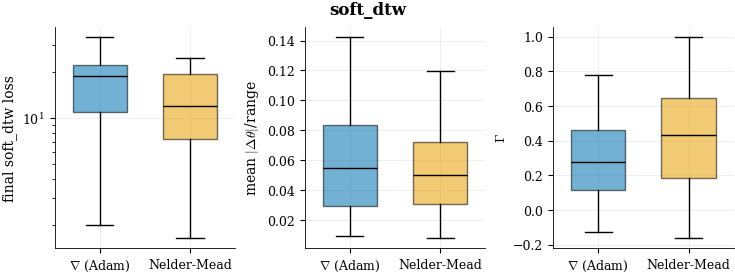

In [6]:
def fig_fit_quality(loss):
    index = LOSS_DATA[loss]["index"]
    fig, axes = plt.subplots(1, 3, figsize=(7.4, 2.8), constrained_layout=True)
    specs = [("final_loss", f"final {loss} loss", True),
             ("param_err", r"mean $|\Delta\theta|$/range", False),
             ("gamma", r"$\Gamma$", False)]
    for ax, (metric, ylab, logy) in zip(axes, specs):
        data = []
        for m in ("grad", "nm"):
            vals = [get_metric(index[k], metric) for k in index
                    if k[1] == m and not _errored(index[k])]
            data.append([v for v in vals if np.isfinite(v)])
        bp = ax.boxplot(data, tick_labels=[LABELS["grad"], LABELS["nm"]],
                        showfliers=False, patch_artist=True, widths=0.6)
        for patch, m in zip(bp["boxes"], ("grad", "nm")):
            patch.set_facecolor(COLORS[m]); patch.set_alpha(0.55)
        for med in bp["medians"]:
            med.set_color("black")
        if logy:
            ax.set_yscale("log")
        ax.set_ylabel(ylab)
    fig.suptitle(loss, fontweight="bold")
    fig.savefig(FIGS / f"spiking_{loss}_fit_quality.pdf")
    plt.show()


for loss in LOSSES:
    fig_fit_quality(loss)

## Figure 4 — example convergence trajectories, per loss

A few individual scenarios (not aggregated), gradient descent and Nelder-Mead
overlaid, in the same **best-so-far** view as Fig 1 (set `BEST_SO_FAR=False` to
see the raw per-epoch overshoot instead). For each base the easiest (smallest δ)
and hardest (largest δ) scenario are shown. One figure per loss, saved to
`figures/spiking_<loss>_example_trajectories.pdf`.

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


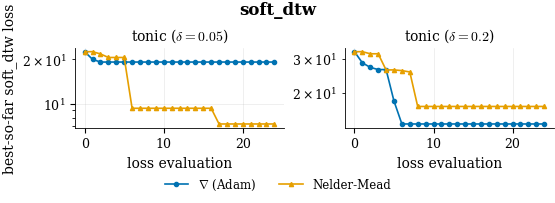

In [7]:
def _run_curve(by_run, index, sid, opt):
    base = index[(sid, opt)]["base"]
    pts = sorted(by_run[(sid, base, opt)])
    return curve_view([p[1] for p in pts])  # best-so-far view (see BEST_SO_FAR)


def _examples(index, sids, by_run):
    """Easiest/hardest-delta scenario per base, restricted to scenarios with both
    optimizers' curves present (non-errored)."""
    out = []
    for base in BASES:
        sids_b = [s for s in sids
                  if (s, "grad") in index and index[(s, "grad")]["base"] == base
                  and (s, base, "grad") in by_run and (s, base, "nm") in by_run]
        if not sids_b:
            continue
        lo = min(sids_b, key=lambda s: _f(index[(s, "grad")]["delta"]))
        hi = max(sids_b, key=lambda s: _f(index[(s, "grad")]["delta"]))
        out += [(lo, base, _f(index[(lo, "grad")]["delta"])),
                (hi, base, _f(index[(hi, "grad")]["delta"]))]
    return out


def fig_example_trajectories(loss):
    LD = LOSS_DATA[loss]
    index, sids, by_run = LD["index"], LD["sids"], LD["by_run"]
    examples = _examples(index, sids, by_run)
    if not examples:
        print(f"[{loss}] no complete example scenarios — skipping")
        return
    fig, axes = plt.subplots(len(BASES), 2, figsize=(5.6, 2.1 * len(BASES)),
                             constrained_layout=True, squeeze=False)
    for ax, (sid, base, delta) in zip(axes.ravel(), examples):
        for m in ("grad", "nm"):
            y = _run_curve(by_run, index, sid, m)
            ax.plot(np.arange(len(y)), y, color=COLORS[m], marker=MARKERS[m],
                    markersize=3, linewidth=1.2, label=LABELS[m])
        ax.set_yscale("log")
        ax.set_title(rf"{base.replace('_', ' ')} ($\delta={delta:g}$)")
    for ax in axes[-1]:
        ax.set_xlabel("loss evaluation")
    for ax in axes[:, 0]:
        ax.set_ylabel(_curve_ylabel(loss))
    fig.suptitle(loss, fontweight="bold")
    h, l = axes[0, 0].get_legend_handles_labels()
    fig.legend(h, l, loc="outside lower center", ncol=2)
    fig.savefig(FIGS / f"spiking_{loss}_example_trajectories.pdf")
    plt.show()


for loss in LOSSES:
    fig_example_trajectories(loss)

## Figure 5 — fitted voltage traces (example scenarios), per loss

For the same example scenarios, the simulated voltage trace **after fitting**
(dashed) overlaid on the ground-truth target (black). Each optimizer's recovered
`v_T, delta_T, v_reset` (from the summary CSV) are plugged back into a clean,
non-surrogate simulation; spike peaks are re-injected (as in the benchmark's GT
trace) so the spikes line up visually. The seeded scenario traces are regenerated
once via the benchmark module (the CSV stores only fitted params, not the GT
trace) and reused across losses. One figure per loss, saved to
`figures/spiking_<loss>_example_fits.pdf`.

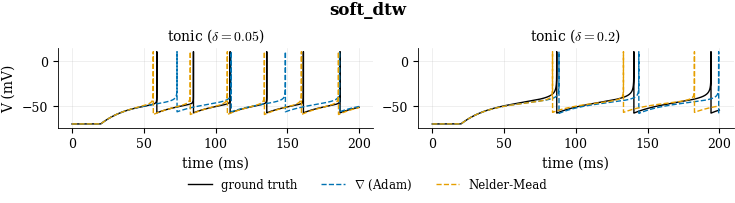

In [8]:
import benchmark_spiking as B

# Scenarios are seeded and loss-independent -> regenerate once, reuse per loss.
scenarios_by_id = {sc["scenario_idx"]: sc for sc in B.generate_scenarios()}


def fig_example_fits(loss):
    LD = LOSS_DATA[loss]
    index, sids, by_run = LD["index"], LD["sids"], LD["by_run"]
    examples = _examples(index, sids, by_run)
    if not examples:
        print(f"[{loss}] no complete example scenarios — skipping")
        return
    fig, axes = plt.subplots(len(BASES), 2, figsize=(7.4, 2.1 * len(BASES)),
                             constrained_layout=True, squeeze=False)
    for ax, (sid, base, delta) in zip(axes.ravel(), examples):
        sc = scenarios_by_id[sid]
        assert sc["base"] == base, "scenario regeneration is out of sync with the CSV"
        trace = sc["trace"]
        ax.plot(trace.time, trace.voltage, color="black", linewidth=1.0,
                label="ground truth")
        for m in ("grad", "nm"):
            fitted = {p: _f(index[(sid, m)][f"{p}_fit"]) for p in B.TRAINABLE}
            params = {**sc["init"], **fitted}
            with B._silence():
                sim = B.simulate_with_current_trace(
                    params=params, current_trace_pA=trace.current, dt_ms=B.DT_MS,
                    use_surrogate=False, v_init=float(trace.voltage[0]))
            v = np.asarray(sim.voltage)[:len(trace.time)].copy()
            for st in sim.spike_times:                  # re-inject peaks like the GT
                idx = int(st / B.DT_MS)
                if 0 <= idx < len(v):
                    v[idx] = B.SPIKE_PEAK_MV
            ax.plot(trace.time[:len(v)], v, color=COLORS[m], linewidth=1.0,
                    linestyle="--", label=LABELS[m])
        ax.set_title(rf"{base.replace('_', ' ')} ($\delta={delta:g}$)")
    for ax in axes[-1]:
        ax.set_xlabel("time (ms)")
    for ax in axes[:, 0]:
        ax.set_ylabel("V (mV)")
    fig.suptitle(loss, fontweight="bold")
    h, l = axes[0, 0].get_legend_handles_labels()
    fig.legend(h, l, loc="outside lower center", ncol=3)
    fig.savefig(FIGS / f"spiking_{loss}_example_fits.pdf")
    plt.show()


for loss in LOSSES:
    fig_example_fits(loss)

## Cross-loss comparison — which loss recovers the params best?

Raw loss values are not comparable across losses, so this section ranks the
losses on the **loss-agnostic** evaluation metrics computed from the clean
non-surrogate re-sim, restricted to the `grad` optimizer (the method under test):

- **Γ** (coincidence factor, higher = better) — the headline success metric.
- **P(accuracy success)** — first-spike err < 5 ms **and** rate err < 10 %.
- **mean |Δθ|/range** — normalized parameter-recovery error (lower = better).
- first-spike error, rate error, wall-clock — secondary diagnostics.

The summary table reports medians (P(success) is a mean of the 0/1 outcome). The
"best" loss is ranked by P(success), then median Γ. Pairwise Wilcoxon tests
(paired on `scenario_idx`) compare the top loss against each other loss on Γ and
parameter error. A grouped figure (`spiking_loss_comparison.pdf`) shows Γ, param
error, and P(success) per loss.

In [9]:
def loss_values(loss, opt, metric):
    """All non-errored per-run values of `metric` for one loss × optimizer."""
    index = LOSS_DATA[loss]["index"]
    out = []
    for k, row in index.items():
        if k[1] != opt or _errored(row):
            continue
        if metric == "accuracy_success":
            v = _f(row["accuracy_success"])
            if v not in (0, 1):
                continue
        else:
            v = get_metric(row, metric)
            if not np.isfinite(v):
                continue
        out.append(v)
    return np.array(out)


def loss_stat(loss, opt, metric):
    """Mean for the binary success rate, median otherwise; nan if empty."""
    v = loss_values(loss, opt, metric)
    if len(v) == 0:
        return float("nan")
    return float(np.mean(v) if metric == "accuracy_success" else np.median(v))


def paired_cross(loss_a, loss_b, opt, metric):
    """Paired (loss_a, loss_b) arrays on common scenario_idx for one optimizer."""
    ia, ib = LOSS_DATA[loss_a]["index"], LOSS_DATA[loss_b]["index"]
    sids = sorted({s for s, o in ia if o == opt} & {s for s, o in ib if o == opt})
    av, bv = [], []
    for s in sids:
        ra, rb = ia.get((s, opt)), ib.get((s, opt))
        if ra is None or rb is None or _errored(ra) or _errored(rb):
            continue
        va, vb = get_metric(ra, metric), get_metric(rb, metric)
        if not (np.isfinite(va) and np.isfinite(vb)):
            continue
        av.append(va); bv.append(vb)
    return np.array(av), np.array(bv)


SUMMARY = [("gamma", "med Gamma", True), ("accuracy_success", "P(success)", True),
           ("param_err", "med |dth|/rng", False),
           ("first_spike_err_ms", "med t1 err ms", False),
           ("rate_rel_err", "med rate err", False),
           ("elapsed_s", "med wall s", False)]

print(f"CROSS-LOSS SUMMARY  (optimizer = {METHOD})")
print("=" * 86)
print(f"{'loss':<13}{'n':>4}" + "".join(f"{lab:>15}" for _, lab, _ in SUMMARY))
for loss in LOSSES:
    n = len(loss_values(loss, METHOD, "gamma"))
    cells = "".join(f"{loss_stat(loss, METHOD, m):>15.4g}" for m, _, _ in SUMMARY)
    print(f"{loss:<13}{n:>4}{cells}")


def _score(loss):
    return (loss_stat(loss, METHOD, "accuracy_success"),
            loss_stat(loss, METHOD, "gamma"))


ranked = sorted([l for l in LOSSES if len(loss_values(l, METHOD, "gamma"))],
                key=lambda l: tuple(-1 if np.isnan(x) else x for x in _score(l)),
                reverse=True)
best = ranked[0] if ranked else None
print(f"\nRanking (P(success), then Gamma): {', '.join(ranked)}")
print(f"--> best loss for {METHOD}: {best}")

if best is not None and len(ranked) > 1:
    print(f"\nPairwise vs best ({best}), {METHOD}, paired on scenario_idx:")
    print(f"{'vs loss':<13}{'metric':<14}{'n':>4}{'med(best-other)':>17}{'best win%':>11}{'p':>9}")
    for other in ranked[1:]:
        for metric, hb in (("gamma", True), ("param_err", False)):
            a, b = paired_cross(best, other, METHOD, metric)
            p, win, med = wilcoxon_report(a, b, higher_better=hb)
            print(f"{other:<13}{metric:<14}{len(a):>4}{med:>17.4g}{100*win:>10.0f}%{p:>9.3f}")

CROSS-LOSS SUMMARY  (optimizer = grad)
loss            n      med Gamma     P(success)  med |dth|/rng  med t1 err ms   med rate err     med wall s
soft_dtw       60         0.2768         0.3167        0.05464           7.35         0.2857          1.146

Ranking (P(success), then Gamma): soft_dtw
--> best loss for grad: soft_dtw


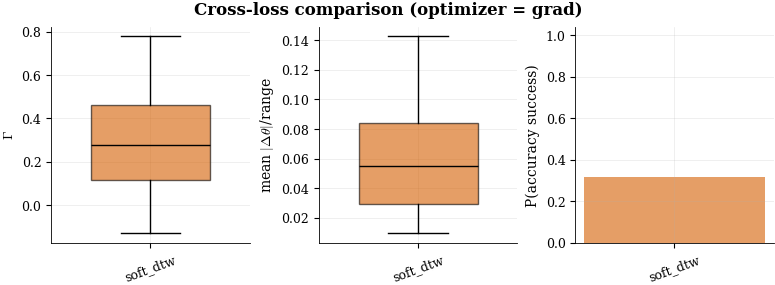

In [10]:
# Losses with at least one non-errored grad run, kept in the ranked order.
PLOT_LOSSES = ranked if ranked else \
    [l for l in LOSSES if len(loss_values(l, METHOD, "gamma"))]

fig, axes = plt.subplots(1, 3, figsize=(7.8, 2.9), constrained_layout=True)


def _box(ax, metric, ylab, logy=False):
    data = [loss_values(loss, METHOD, metric) for loss in PLOT_LOSSES]
    data = [d if len(d) else np.array([np.nan]) for d in data]
    bp = ax.boxplot(data, tick_labels=PLOT_LOSSES, showfliers=False,
                    patch_artist=True, widths=0.6)
    for patch, loss in zip(bp["boxes"], PLOT_LOSSES):
        patch.set_facecolor(loss_color(loss)); patch.set_alpha(0.6)
    for med in bp["medians"]:
        med.set_color("black")
    if logy:
        ax.set_yscale("log")
    ax.set_ylabel(ylab)
    ax.tick_params(axis="x", rotation=20)


_box(axes[0], "gamma", r"$\Gamma$")
_box(axes[1], "param_err", r"mean $|\Delta\theta|$/range")

# (c) P(accuracy success) as a bar
ax = axes[2]
ys = [loss_stat(loss, METHOD, "accuracy_success") for loss in PLOT_LOSSES]
ax.bar(range(len(PLOT_LOSSES)), ys,
       color=[loss_color(l) for l in PLOT_LOSSES], alpha=0.6)
ax.set_xticks(range(len(PLOT_LOSSES)))
ax.set_xticklabels(PLOT_LOSSES, rotation=20)
ax.set_ylabel("P(accuracy success)"); ax.set_ylim(0, 1.04)

fig.suptitle(f"Cross-loss comparison (optimizer = {METHOD})", fontweight="bold")
fig.savefig(FIGS / "spiking_loss_comparison.pdf")
plt.show()